This is a notebook for computing deep foundation axial geotechnical capacity. <br>
Author: Zhiyan Jiang [(linkedin.com/in/zhiyanjiang)](http://www.linkedin.com/in/zhiyanjiang)

In [54]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
#import numpy as np
import matplotlib.pyplot as plt
import yaml

In [56]:
from deep_foundation_bearing_capacity.cross_sections.cross_sections import CircularSection, CrossSection
from deep_foundation_bearing_capacity.factor_of_safety.factor_of_safety import FactorOfSafetyDeepFoundation
from deep_foundation_bearing_capacity.foundation.deep_foundation import DeepFoundation
from deep_foundation_bearing_capacity.foundation.foundation_material import FoundationConcrete
from deep_foundation_bearing_capacity.segments.segments import Segment
from deep_foundation_bearing_capacity.segments.unit_resistance import EndResistance, SideResistance
from deep_foundation_bearing_capacity.soil_layer.layer import Layer
from deep_foundation_bearing_capacity.soil_layer.soil import Soil

In [57]:
# Read soil parameters from YAML
with open("data/soil_params.yaml") as f:
    soils = yaml.safe_load(f)

soil_obj_list = []
for soil in soils:
    soil_obj = Soil.from_dict(soil)
    soil_obj_list.append(soil_obj)

    soil_obj.display_properties()
    print()
    

soil_index is: 0
unit_weight is: 120.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 5

soil_index is: 1
unit_weight is: 120.0
cohesion is: 500.0
friction_angle is: 0.0
n60 is: 6

soil_index is: 2
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 10

soil_index is: 3
unit_weight is: 115.0
cohesion is: 2000.0
friction_angle is: 0.0
n60 is: 6

soil_index is: 4
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 19

soil_index is: 5
unit_weight is: 130.0
cohesion is: 4000.0
friction_angle is: 0.0
n60 is: 19

soil_index is: 6
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 26

soil_index is: 7
unit_weight is: 130.0
cohesion is: 200.0
friction_angle is: 0.0
n60 is: 26

soil_index is: 8
unit_weight is: 130.0
cohesion is: 0.0
friction_angle is: 0.0
n60 is: 20

soil_index is: 9
unit_weight is: 130.0
cohesion is: 8000.0
friction_angle is: 0.0
n60 is: 20

soil_index is: 10
unit_weight is: 115.0
cohesion is: 0.0
friction_angle is: 30.0

In [58]:
# Read layer parameters from YAML

with open("data/layer_params.yaml") as f:
    layers = yaml.safe_load(f)


layer_obj_list = []
layer_index = 0
for layer in layers:

    layer_obj = Layer(layer_index, soil_obj_list[layer["soil_index"]], layer["ground_water_depth"], layer["top_depth"], layer["thickness"])
    layer_obj_list.append(layer_obj)
    layer_index = layer_index + 1

    layer_obj.display_properties()
    print()


layer_index is: 0
ground_water_depth is: 15.0
top_depth is: 0
thickness is: 10

layer_index is: 1
ground_water_depth is: 15.0
top_depth is: 10
thickness is: 5

layer_index is: 2
ground_water_depth is: 15.0
top_depth is: 15
thickness is: 10

layer_index is: 3
ground_water_depth is: 15.0
top_depth is: 25
thickness is: 10

layer_index is: 4
ground_water_depth is: 15.0
top_depth is: 35
thickness is: 10

layer_index is: 5
ground_water_depth is: 15.0
top_depth is: 45
thickness is: 10

layer_index is: 6
ground_water_depth is: 15.0
top_depth is: 55
thickness is: 10

layer_index is: 7
ground_water_depth is: 15.0
top_depth is: 65
thickness is: 10

layer_index is: 8
ground_water_depth is: 15.0
top_depth is: 75
thickness is: 10

layer_index is: 9
ground_water_depth is: 15.0
top_depth is: 85
thickness is: 10

layer_index is: 10
ground_water_depth is: 15.0
top_depth is: 95
thickness is: 10

layer_index is: 11
ground_water_depth is: 15.0
top_depth is: 105
thickness is: 10



In [59]:
# test SideResistance class for cohesive layer
side_resistance_obj_1 = SideResistance(layer_obj_list[0])
print(f"First layer beta is: {side_resistance_obj_1._calculate_beta():.2f}")

# test SideResistance class for cohesive layer
side_resistance_obj_2 = SideResistance(layer_obj_list[1])
print(f"Second layer alpha is: {side_resistance_obj_2._calculate_alpha():.2f}")

First layer beta is: 0.40
Second layer alpha is: 0.55


In [60]:
# test EndResistance class for cohesionless layer
end_resistance_obj_1 = EndResistance(layer_obj_list[0])
print(f"Top layer unit end resistance is: {end_resistance_obj_1.end_resistance_unit():.2f}")

Top layer unit end resistance is: 6000.00


In [61]:
# test EndResistance class for cohesionless layer
end_resistance_obj_2 = EndResistance(layer_obj_list[1])
print(f"Second layer unit end resistance is: {end_resistance_obj_2.end_resistance_unit():.2f}")

Second layer unit end resistance is: 3250.00


In [62]:
# test CrossSection class
cross_section_diameter = 1.5
print(f"Cross section diameter is: {cross_section_diameter}")
cross_section_obj = CircularSection(1.5)
print(f"Cross section area is: {cross_section_obj.cross_section_area:.2f}")
print(f"Cross section perimeter is: {cross_section_obj.perimeter:.2f}")

Cross section diameter is: 1.5
Cross section area is: 1.77
Cross section perimeter is: 4.71


In [63]:
# test Segment class
segment_obj_list = []
foundation_concrete_obj = FoundationConcrete()

for layer_obj in layer_obj_list:
    segment_obj = Segment(cross_section_obj, layer_obj, foundation_concrete_obj)
    segment_obj_list.append(segment_obj)



In [64]:
print(f"Top segment side surface area is: {segment_obj_list[0].side_surface_area:.2f}")

Top segment side surface area is: 47.12


In [65]:
# test DeepFoundation class
top_depth = 0

deep_foundation_obj = DeepFoundation(segment_obj_list, top_depth,  resistance_corrections = None)

# test DeepFoundation method for self weight
print(f"Concrete foundation self weight is: {deep_foundation_obj.effective_weight:.0f} lb.")

Concrete foundation self weight is: 19456 lb.


In [66]:
# test DeepFoundation method for calculating effective stress
print(f"Deep foundation effective stresses are: {deep_foundation_obj.calculate_segment_effective_stresses}")

Deep foundation effective stresses are: [600.0, 1500.0, 2063.0, 2589.0, 3190.0, 3866.0, 4542.0, 5218.0, 5894.0, 6570.0, 7171.0, 7722.0]


In [67]:
# test FactorOfSafety class
fs = 3.0
print(f"Factor of safety is prescribed as: {fs}")
fs_obj = FactorOfSafetyDeepFoundation(3, 3)

Factor of safety is prescribed as: 3.0


In [68]:
# test DeepFoundation side resistance
deep_foundation_obj.calculate_segment_side_resistances(uplift = False)

[11292.116975082572,
 6479.534848028948,
 58087.66413196619,
 51836.27878423158,
 97137.89961145465,
 96318.16490714399,
 97235.6982664023,
 5183.627878423159,
 81247.81975530267,
 169646.00329384883,
 84481.35344584651,
 25918.13939211579]

In [69]:
# test DeepFoundation side resistance
deep_foundation_obj.calculate_segment_side_resistances(uplift = True)

[8469.087731311929,
 6479.534848028948,
 43565.74809897464,
 51836.27878423158,
 72853.42470859097,
 96318.16490714399,
 72926.77369980172,
 5183.627878423159,
 60935.864816477,
 169646.00329384883,
 63361.01508438489,
 25918.13939211579]

In [70]:
# test DeepFoundation accumulative side resistance 
for segment_side_resistance_accumulative, segment_end_resistance in zip(
deep_foundation_obj.calculate_segment_side_resistances_accumulative(),
deep_foundation_obj.calculate_segment_end_resistances()
):
    print(f"{segment_side_resistance_accumulative:.0f}, {segment_end_resistance:.0f}")

11292, 10603
17772, 5743
75859, 21206
127696, 31809
224833, 40291
321152, 63617
418387, 55135
423571, 2297
504819, 42412
674465, 127235
758946, 63617
784864, 14137


In [71]:
# test DeepFoundation accumulative compression resistance
print("Accumulative compression resistance is:")
for temp in deep_foundation_obj.calculate_compression_resistances_accumulative():
    print(f"{temp:.0f} lb.")

Accumulative compression resistance is:
21895 lb.
23515 lb.
97065 lb.
159504 lb.
265124 lb.
384769 lb.
473522 lb.
425868 lb.
547230 lb.
801699 lb.
822563 lb.
799001 lb.


In [72]:
# test DeepFoundation calculate_segment_weights_accumulative
print("Accumulative self weight is: ")
deep_foundation_obj.calculate_segment_weights_effective_accumulative()

Accumulative self weight is: 


[2650.718801466388,
 3976.078202199582,
 5524.097982255953,
 7072.117762312324,
 8620.137542368695,
 10168.157322425066,
 11716.177102481437,
 13264.196882537808,
 14812.216662594179,
 16360.23644265055,
 17908.25622270692,
 19456.27600276329]

In [73]:
# test DeepFoundation accumulative uplift resistance
print("Accumulative compression resistance is:")
for temp in deep_foundation_obj.calculate_uplift_resistances_accumulative():
    print(f"{temp:.0f} lb.")

Accumulative compression resistance is:
11120 lb.
18925 lb.
64038 lb.
117423 lb.
191824 lb.
289690 lb.
364165 lb.
370897 lb.
433381 lb.
604575 lb.
669484 lb.
696950 lb.


In [74]:
# Test plotting compression accumulative resistancedeep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "piecewise")

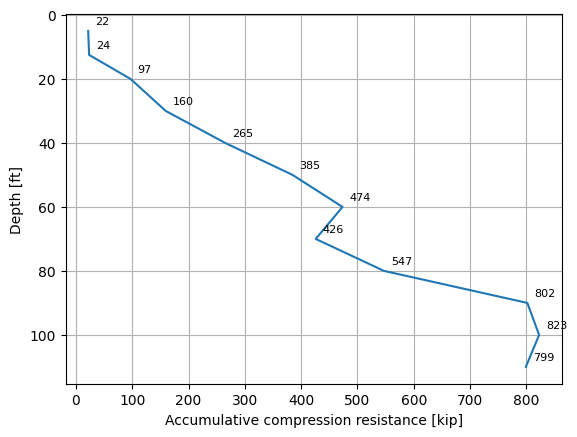

In [75]:
deep_foundation_obj.visualize_resistances_accumulative(target = "compression", style = "mid")

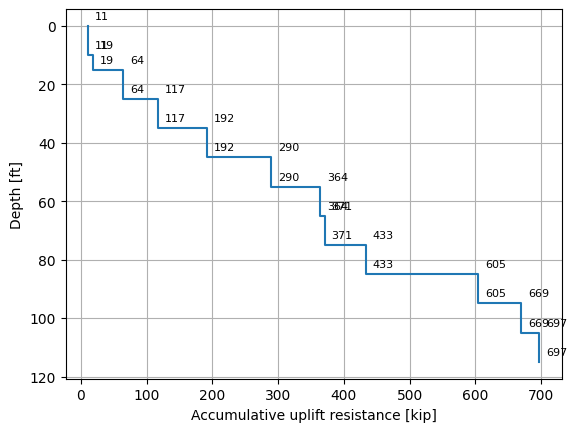

In [76]:
# Test plotting uplift accumulative resistance
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "piecewise")


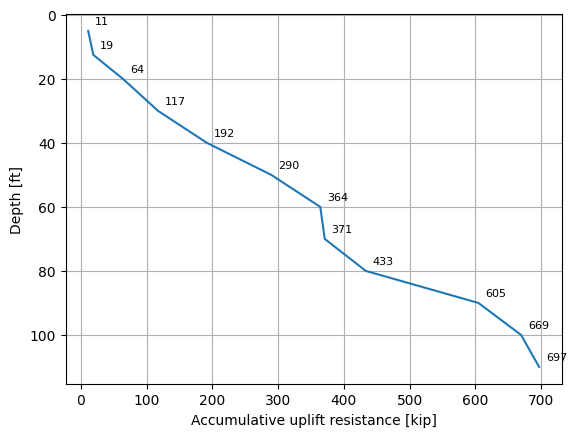

In [77]:
deep_foundation_obj.visualize_resistances_accumulative(target = "uplift", style = "mid")

In [82]:
# Test structural compression capacity
print("Each segment's structural capacity in compression is: ")
deep_foundation_obj.segments_structural_capacity_compression()

Each segment's structural capacity in compression is: 


[335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207,
 335899.0865218207]

In [78]:
# Test side resistance correction
#deep_foundation_obj = DeepFoundation([segment_obj_1, segment_obj_2], top_depth, resistance_correction=True)
#print(f"With depth correction, second segment side resistance is: {deep_foundation_obj.segments[1].side_resistance}")